In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
print(GIT_REPO)
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()

CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [2]:
print(GIT_REPO)


/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis


# Load ntuples

In [4]:
limitTrees =OrderedDict()
dataCards = OrderedDict()
limits = OrderedDict()
ctaus = np.array([1,3,5,10,30,50,100,300,500,1000,2000,3000,5000,8000,10000,30000,50000,100000])
mass = [15]
decays = ['B',]
### limit branch: 2.5, 16.0, 50.0, 84.0, 97.5, obs
expected = ['0.025', '0.160','0.500','0.840','0.975']

categories = ['csccsc','dtcsc','dtdt','combine']
# categories = ['combine']
datacard_version = 'limits_v5'
for cat in categories:
    cardDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3MET/{datacard_version}/"
    treeDir = cardDir.replace("datacards","limitTrees")
    limitTrees[cat] = {}
    dataCards[cat] = {}
    if cat == "csccsc":cat_name = "csc2"
    elif cat == "dtdt":cat_name = "dt2"
    elif cat == "dtcsc": cat_name = "csc_dt"
    else:cat_name = "combined"
    
    for decay in decays:
        for m in mass:
            if decay == 'B' and m < 15:continue
            if decay == 'Tau' and m < 7:continue
            key = f"ggH_Hto2Sto4{decay}_MH-125-MS-{m}"
            limitTrees[cat][key] = {}
            dataCards[cat][key] = {}

            for ct in ctaus:
                card_name = f'{cat_name}_{ct}.0'
                dataCards[cat][key][ct] = f'{cardDir}/{key}/All/{card_name}.txt'
                limitTrees[cat][key][ct] = f'{treeDir}/{key}/All/higgsCombine.{card_name}.AsymptoticLimits.mH120.root'
    limits[cat] = {}
    for i,m in enumerate(limitTrees[cat].keys()):
        limits[cat][m] = np.ones((len(ctaus), 5))*1000000
        for j, k in enumerate(limitTrees[cat][m].keys()):

            if not os.path.isfile(limitTrees[cat][m][k]):
                print(limitTrees[cat][m][k])
                continue
            if not os.path.isfile(dataCards[cat][m][k]):
                print(dataCards[cat][m][k])
                continue
            line = open(dataCards[cat][m][k], "r").readline()
            if not line[0] == '#' :continue
            signal_norm = float(line.split("=")[-1])
            if signal_norm == 0:continue

            if len(uproot.open(limitTrees[cat][m][k]).keys()) == 2:
                T = uproot.open(limitTrees[cat][m][k])['limit']                
                if len(np.array(T['limit'].array())>0):limits[cat][m][j] = np.array(T['limit'].array())/signal_norm
        limits[cat][m] = np.array(limits[cat][m])
    print(ctaus)

[     1      3      5     10     30     50    100    300    500   1000
   2000   3000   5000   8000  10000  30000  50000 100000]
[     1      3      5     10     30     50    100    300    500   1000
   2000   3000   5000   8000  10000  30000  50000 100000]
[     1      3      5     10     30     50    100    300    500   1000
   2000   3000   5000   8000  10000  30000  50000 100000]
[     1      3      5     10     30     50    100    300    500   1000
   2000   3000   5000   8000  10000  30000  50000 100000]


# load other limits

In [12]:
file_dir = '/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/data/limits_others/'


# ms_40 = file_dir + 'atlas_mh125_mx40_ms.csv'
# ms_15 = file_dir + 'atlas_mh125_mx15_ms.csv'
# ms_8 = file_dir + 'atlas_mh125_mx8_ms.csv'


other_limits = {}

other_limits['Run2 csccsc'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_CSCCSC.csv' , delimiter=',')
other_limits['Run2 cscdt'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_DTCSC.csv', delimiter=',')
other_limits['Run2 dtdt'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_DTDT.csv', delimiter=',')
other_limits['Run2 2tag'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_2tag_combined.csv', delimiter=',')

# other_limits['EXO-21-008_all'] = np.genfromtxt(file_dir + 'limitsbbbb_m15_hybridNew.txt', delimiter='\t')
# other_limits['EXO-21-008_all'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_all.csv', delimiter='\t')


# plot expected limit 

In [6]:
showOthers  = 1

B
ggH_Hto2Sto4B_MH-125-MS-15
ggH_Hto2Sto4B_MH-125-MS-15 0.003708465242874753 [0.00598958]
[1.24198695e+01 6.63464909e-01 2.82869964e-02 3.98898778e-03
 3.70846524e-03 5.98957648e-03 1.54393154e-02 2.85629096e-02
 6.67723187e-02 1.52137253e-01 2.27213645e-01 1.75828573e+00
 4.71364875e+00 1.83272820e+01]
ggH_Hto2Sto4B_MH-125-MS-15
ggH_Hto2Sto4B_MH-125-MS-15 0.0018264228625990298 [0.00216]
[1.06073796e+01 1.15788493e+00 6.52990616e-02 2.65390230e-03
 1.82642286e-03 2.16000260e-03 7.22783782e-03 1.15116568e-02
 2.36607818e-02 5.06247637e-02 7.43911169e-02 5.66218903e-01
 1.51997070e+00 5.92511970e+00]
ggH_Hto2Sto4B_MH-125-MS-15
ggH_Hto2Sto4B_MH-125-MS-15 0.0011784712556877327 [0.00150152]
[4.51315407e+01 2.86192157e+00 4.24572346e-02 1.66474681e-03
 1.17847126e-03 1.50151998e-03 2.75622211e-03 5.13391132e-03
 1.22153913e-02 2.86208224e-02 4.34085760e-02 3.61738068e-01
 9.88781113e-01 3.90756695e+00]
ggH_Hto2Sto4B_MH-125-MS-15
ggH_Hto2Sto4B_MH-125-MS-15 0.000767791878705644 [0.00097371]
[9

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/met_combine_ggH_Hto2Sto4B_MH-125-MS-15_expected_compareRun2.pdf has been created
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/met_combine_ggH_Hto2Sto4B_MH-125-MS-15_expected_compareRun2.png has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/met_combine_ggH_Hto2Sto4B_MH-125-MS-15_expected_compareRun2.C has been generated


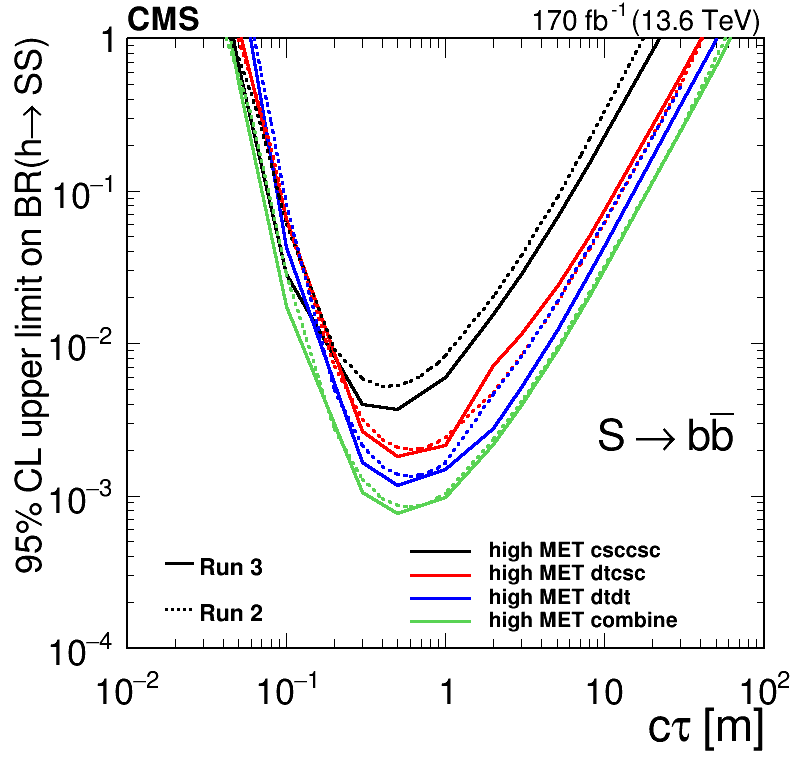

In [22]:
import os
import importlib
importlib.reload(sys.modules['CMS_lumi'])

opac_1sig = 0.25
opac_2sig = 0.1

print(decay)
leg = rt.TLegend(0.5,0.18,0.93,0.30)
leg2 = rt.TLegend(0.2,0.18,0.40,0.30)
leg.SetTextSize(0.03)
leg.SetBorderSize(0)
leg.SetEntrySeparation(0.01)
leg2.SetTextSize(0.032)
leg2.SetBorderSize(0)
leg2.SetEntrySeparation(0.01)


c = rt.TCanvas('c','c', 800, 800)
c.SetRightMargin(0.04)

rt.gStyle.SetOptFit(1011)
ctaus_m = ctaus/1000
#     print(ctaus_m)
h = {}
h_exp1sig = {}
h_exp2sig = {}
h_obs = {}
h_others = {}
h_others_obs = {}
h_others_1sig = {}
for i, cat in enumerate(categories):
    
    
    for m in limits[cat].keys():
        print(m)
        if m not in limits[cat].keys():continue
        cond = limits[cat][m][:,2] < 1000000
        if np.count_nonzero(cond)==0:print(m, cat)
        key = f"{cat}_{m}"
        h[key] = create_TGraph(ctaus_m[cond], limits[cat][m][:,2][cond],  axis_title=['c#tau [m]', '95% CL upper limit on BR(h#rightarrow SS)'])
        h_exp1sig[key] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[cat][m][:,1][cond], np.flip(limits[cat][m][:,3][cond]))))
        mass_str = m[m.find('ms')+2:].replace('p','.')
        print(m,np.min(limits[cat][m][:,2][cond]), limits[cat][m][:,2][cond][ctaus_m[cond]==1])
        if '15' in m:print(limits[cat][m][:,2][cond])
        leg.AddEntry(h[key], f" high MET {cat}", "L")
        if i == 0: leg2.AddEntry(h[key], f"Run 3", "L")

        if not showOthers:leg.AddEntry(h_exp1sig[key], "#pm 1 #sigma Expected", 'F')

        h_exp1sig[key].SetFillColorAlpha(std_color_list[i],opac_1sig)
        h[key].SetLineColor(std_color_list[i])
        h[key].SetMarkerColor(std_color_list[i])

        h[key].SetLineWidth(3)

        h[key].SetLineStyle(1)
        if decay == 'd' or decay == 'B' or decay == 'Tau': h[key].GetXaxis().SetLimits(0.01,100.0)
        else: h[key].GetXaxis().SetLimits(0.0001,100.0)
        h[key].GetYaxis().SetRangeUser(1e-4,1)

        h[key].GetXaxis().SetTitleOffset(1)
        h[key].GetYaxis().SetTitleSize(0.05)
        h[key].GetYaxis().SetTitleOffset(1.5)
        
for i,m in enumerate(h.keys()):
    h[m].Draw('LA' if i == 0 else 'Lsame')
    if not showOthers: h_exp1sig[m].Draw('Fsame')
    print(m)
    
if showOthers:
    for i,k in enumerate(other_limits.keys()):
            h_others[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,3],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
            h_others_obs[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,6],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
            h_others_1sig[k] = create_TGraph(np.hstack((other_limits[k][:,0], np.flip(other_limits[k][:,0]))),\
                                             np.hstack((other_limits[k][:,2], np.flip(other_limits[k][:,4]))),  axis_title=['c#tau [m]', '95% CL Limit on BR'])
            if i == 0: leg2.AddEntry(h_others[k], "Run 2", 'L')
            h_others[k].SetLineWidth(3)
            h_others_obs[k].SetLineWidth(3)
            h_others_obs[k].SetLineStyle(2)
            h_others[k].SetLineStyle(2)


            h_others_obs[k].SetLineColor(std_color_list[i])
            h_others[k].SetLineColor(std_color_list[i])
            h_others[k].SetMarkerColor(std_color_list[i])
            h_others_1sig[k].SetFillColorAlpha(std_color_list[i], opac_1sig)
            # h_others_obs[k].Draw("Lsame")
            h_others[k].Draw('Lsame')
            # h_others_1sig[k].Draw('Fsame')


tdrstyle.setTDRStyle()
CMS_lumi.cmsText     = "CMS"
iPos = 0
CMS_lumi.writeExtraText = 0
CMS_lumi.extraText   = "Preliminary"

if( iPos==0 ): CMS_lumi.relPosX = 0.12
# CMS_lumi.CMS_lumi(c, 4, 0)
CMS_lumi.lumi_13p6TeV = '170 fb^{-1}'
CMS_lumi.CMS_lumi(c, 5, iPos)


# leg.SetNColumns(2)

leg.Draw()
leg2.Draw()
c.SetLogy()
c.SetLogx()
c.SetTicky(1)
c.SetTickx(1)


latex = rt.TLatex()
latex.SetTextSize(0.06)
latex.SetTextFont(42)

if decay == 'd': latex.DrawLatex(9,0.002,  "S #rightarrow d#bar{d}")
elif decay == 'B': latex.DrawLatex(9,0.002, "S #rightarrow b#bar{b}")
elif decay == 'Tau': latex.DrawLatex(9,0.002, "S #rightarrow #tau^{+}#tau^{-}")

if showOthers:
    c.SaveAs(GIT_REPO + f"/limits/met_{m}_expected_compareRun2.pdf")
    c.SaveAs(GIT_REPO + f"/limits/met_{m}_expected_compareRun2.png")
    c.SaveAs(GIT_REPO + f"/limits/met_{m}_expected_compareRun2.C")
else:
    c.SaveAs(GIT_REPO + f"/limits/met_{m}_expected_compare.pdf")
    c.SaveAs(GIT_REPO + f"/limits/met_{m}_expected_compare.png")
    c.SaveAs(GIT_REPO + f"/limits/met_{m}_expected_compare.C")

tdrstyle.setTDRStyle()
c.Draw()

In [ ]:
import os
import importlib
importlib.reload(sys.modules['CMS_lumi'])


opac_1sig = 0.25
opac_2sig = 0.1
for decay in decays:
    print(decay)
    leg = rt.TLegend(0.6,0.18,0.95,0.35)
    leg.SetTextSize(0.03)
    leg.SetBorderSize(0)
    leg.SetEntrySeparation(0.01)
  
    
    
    c = rt.TCanvas('c','c', 800, 800)
    c.SetRightMargin(0.04)

    rt.gStyle.SetOptFit(1011)
    ctaus_m = ctaus/1000
#     print(ctaus_m)
    h = {}
    h_exp1sig = {}
    h_exp2sig = {}
    h_obs = {}
    h_others = {}
    h_others_1sig = {}
    h_others_obs = {}
    sample_temp = []
    for m in mass:
        if m == 15:sample_temp.append(f"ggH_HToSS_STo4{decay}_ms{m}")
    for i, m in enumerate(sample_temp):
        cond = limits[m][:,2] < 1000000
        

        h[m] = create_TGraph(ctaus_m[cond], limits[m][:,2][cond],  axis_title=['c#tau [m]', '95% CL upper limit on BR(h#rightarrow SS)'])
        h_exp1sig[m] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[m][:,1][cond], np.flip(limits[m][:,3][cond]))))
        mass_str = m[m.find('ms')+2:].replace('p','.')


    
        
        leg.AddEntry(h[m], "m_{S} = "+mass_str+" GeV", "L")
        if leg2.GetNRows() == 0:leg2.AddEntry(h[m], "Median Expected", "L")

        # leg.AddEntry(h_exp1sig[m], "#pm 1 #sigma Expected", 'F')

#         if len(sample_temp) == 3: 
        h_exp1sig[m].SetFillColorAlpha(std_color_list[i],opac_1sig)
        h[m].SetLineColor(std_color_list[i])
        h[m].SetMarkerColor(std_color_list[i])
        h[m].SetLineStyle(1)
        h[m].SetLineWidth(3)
        if decay == 'd' or decay == 'B' or decay == 'Tau': h[m].GetXaxis().SetLimits(0.01,100.0)
        else: h[m].GetXaxis().SetLimits(0.0001,100.0)
        h[m].GetYaxis().SetRangeUser(1e-4,1)

        h[m].GetXaxis().SetTitleOffset(1)
        h[m].GetYaxis().SetTitleSize(0.05)
        h[m].GetYaxis().SetTitleOffset(1.5)



    for i,m in enumerate(h.keys()):
        h[m].Draw('LA' if i == 0 else 'Lsame')
        h_exp1sig[m].Draw('Fsame')

        

    for i,k in enumerate(other_limits.keys()):

            
            
        h_others[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,3],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
        h_others_obs[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,6],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
        h_others_1sig[k] = create_TGraph(np.hstack((other_limits[k][:,0], np.flip(other_limits[k][:,0]))),\
                                         np.hstack((other_limits[k][:,2], np.flip(other_limits[k][:,4]))),  axis_title=['c#tau [m]', '95% CL Limit on BR'])
        leg.AddEntry(h_others[k], k, 'L')
        h_others[k].SetLineWidth(3)
        h_others_obs[k].SetLineWidth(3)
        h_others_obs[k].SetLineStyle(2)
        
        h_others_obs[k].SetLineColor(std_color_list[i+1])
        h_others[k].SetLineColor(std_color_list[i+1])
        h_others[k].SetMarkerColor(std_color_list[i+1])
        h_others_1sig[k].SetFillColorAlpha(std_color_list[i+1], opac_1sig)
        h_others_obs[k].Draw("Lsame")
        h_others[k].Draw('Lsame')
        h_others_1sig[k].Draw('Fsame')  
        
    tdrstyle.setTDRStyle()
    CMS_lumi.cmsText     = "CMS"
    iPos = 0
    CMS_lumi.writeExtraText = 0
    CMS_lumi.extraText   = "Preliminary"

    if( iPos==0 ): CMS_lumi.relPosX = 0.12
    # CMS_lumi.CMS_lumi(c, 4, 0)
    CMS_lumi.CMS_lumi(c, 5, iPos)


    # leg.SetNColumns(2)

    leg.Draw()
#     leg2.Draw()
    c.SetLogy()
    c.SetLogx()
    c.SetTicky(1)
    c.SetTickx(1)


    latex = rt.TLatex()
    latex.SetTextSize(0.06)
    latex.SetTextFont(42)

    if decay == 'd': latex.DrawLatex(200,0.002,  "S #rightarrow d#bar{d}")
    elif decay == 'B': latex.DrawLatex(200,0.002, "S #rightarrow b#bar{b}")
    elif decay == 'Tau': latex.DrawLatex(200,0.002, "S #rightarrow #tau^{+}#tau^{-}")
    # elif decay == 'EE': latex.DrawLatex(1,0.002, "S #rightarrow e^{+}e^{-}")
    # elif decay == 'GammaGamma': latex.DrawLatex(1,0.002, "S #rightarrow #gamma#gamma")
    # elif decay == 'KPlusKMinus': latex.DrawLatex(1,0.002, "S #rightarrow K^{+}K^{-}")
    # elif decay == 'K0K0': latex.DrawLatex(1,0.002, "S #rightarrow K^{0}K^{0}")
    # elif decay == 'Pi0Pi0': latex.DrawLatex(1,0.002, "S #rightarrow #pi^{0}#pi^{0}")
    # elif decay == 'PiPlusPiMinus': latex.DrawLatex(1,0.002, "S #rightarrow #pi^{+}#pi^{-}")

    # output_dir = '/storage/af/user/christiw/gpu/christiw/llp/delayed_jet_analyzer/plots/MuonSystem_Analysis/double_tag/limits/'+version+'/'+dc_version+'/'+unblind+'/'
    # if not os.path.isdir(output_dir):os.makedirs(output_dir)
#     name = output_dir+mode+'_HToSSTo'+decay


#     c.SaveAs(name+'_expected.png')
#     c.SaveAs(name+'_expected.C')
#     c.SaveAs(name+'_expected.pdf')

    tdrstyle.setTDRStyle()
    c.Draw()